## setup


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

## imports



In [2]:
from src.pdf_reader import extract_text_from_pdf
from src.text_processor import process_text
from src.vocab_builder import build_vocabulary
from src.example_extractor import add_example_sentences
from src.vocab_ranker import rank_vocabulary

## load the pdf + quick preview

In [3]:
pdf_path = "../data/raw/book.pdf"
text = extract_text_from_pdf(pdf_path)

print(text[:2000])


PRAISE FOR
A COUNTRY DOCTOR’S NOTEBOOK
“This book has a freshness and liveliness … an epic quality because of the background 
Russia’s vastness, the great distances, the weight of the ignorance, the need.”
—DORIS LESSI
“These straightforward yet extraordinary sketches gain their strength from also being th
account of a young man’s growth. One begins to see that he became a novelist not becau
he had material but because he was storing up passion and temperament.”
—V.S. PRITCHETT, NEW STATESM
“Stories as keen and bright as a scalpel … Courage shines from every angle of th
profoundly human collection by the greatest of modern Russian writers.”
—SUNDAY TIM
“Bulgakov casts a wonderfully wry, self-deprecating humour. His compassion for huma
folly is unfailing … These stories stand testament both to human resilience and 
remarkable literary talent.”
—THE INDEPENDE

A COUNTRY DOCTOR’S NOTEBOOK
MIKHAIL BULGAKOV (1891–1940) was born in Kiev, one of seven children born to a
university lecturer a

## tokenize / inspect

`process_text()`
- original word
- lemma
- part of speech
- stopword flag


In [4]:
tokens = process_text(text)

tokens[:20]

[{'word': 'praise', 'lemma': 'praise', 'pos': 'VERB', 'is_stop': False},
 {'word': 'for', 'lemma': 'for', 'pos': 'ADP', 'is_stop': True},
 {'word': 'a', 'lemma': 'a', 'pos': 'DET', 'is_stop': True},
 {'word': 'country', 'lemma': 'country', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'doctor', 'lemma': 'doctor', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'notebook', 'lemma': 'notebook', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'this', 'lemma': 'this', 'pos': 'DET', 'is_stop': True},
 {'word': 'book', 'lemma': 'book', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'has', 'lemma': 'have', 'pos': 'VERB', 'is_stop': True},
 {'word': 'a', 'lemma': 'a', 'pos': 'DET', 'is_stop': True},
 {'word': 'freshness', 'lemma': 'freshness', 'pos': 'NOUN', 'is_stop': False},
 {'word': 'and', 'lemma': 'and', 'pos': 'CCONJ', 'is_stop': True},
 {'word': 'liveliness',
  'lemma': 'liveliness',
  'pos': 'NOUN',
  'is_stop': False},
 {'word': 'an', 'lemma': 'an', 'pos': 'DET', 'is_stop': True},
 {'word': 'epic'

In [5]:
len(tokens)

47860

In [6]:
vocab_df = build_vocabulary(tokens, min_frequency=2)

vocab_df.head(20)

,lemma,pos,frequency
0,say,VERB,173
1,come,VERB,145
2,woman,NOUN,126
3,doctor,NOUN,120
4,eye,NOUN,112
5,time,NOUN,105
6,look,VERB,94
7,feel,VERB,91
8,think,VERB,91
9,man,NOUN,82


In [7]:
vocab_df.shape

(2382, 3)

In [8]:
vocab_df.sample(20)

,lemma,pos,frequency
2328,urgently,ADV,2
1029,proud,ADJ,4
1872,handwriting,NOUN,2
774,late,ADV,5
2018,near,ADV,2
2146,safety,NOUN,2
229,prescribe,VERB,14
86,table,NOUN,29
671,tub,NOUN,6
1738,diagonally,ADV,2


In [9]:
vocab_df["frequency"].describe()

count    2382.000000
mean        6.761545
std        11.198386
min         2.000000
25%         2.000000
50%         3.000000
75%         6.000000
max       173.000000
Name: frequency, dtype: float64

In [10]:
vocab_df["pos"].value_counts()

pos
NOUN    1146
VERB     664
ADJ      410
ADV      162
Name: count, dtype: int64

## visualization



In [11]:
import matplotlib.pyplot as plt

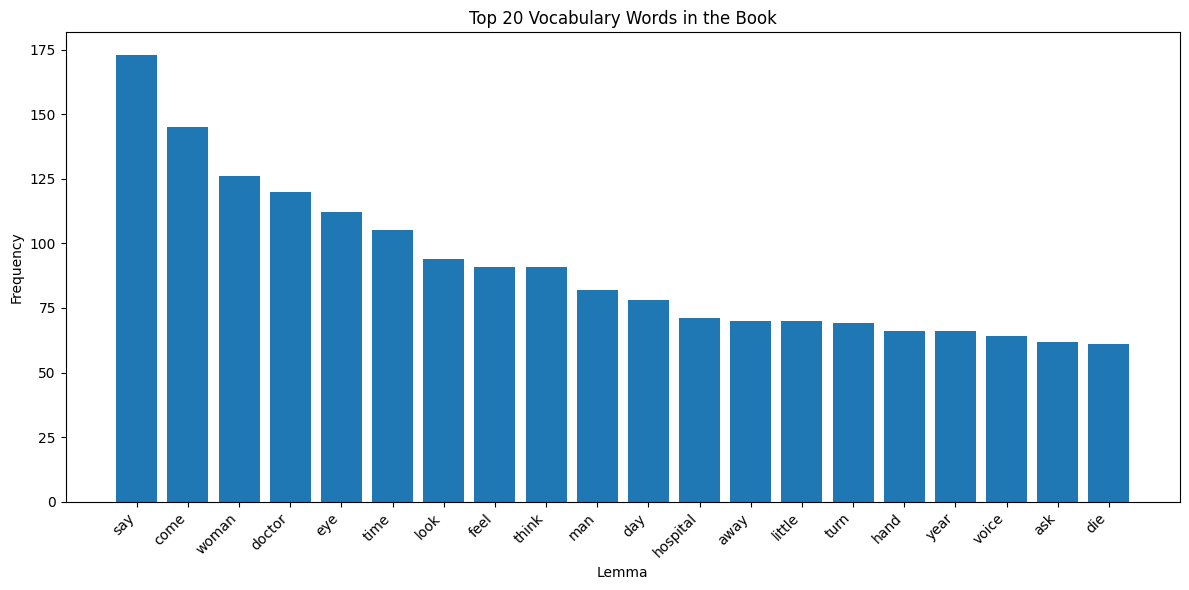

In [12]:
top_n = 20
top_vocab = vocab_df.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(top_vocab["lemma"], top_vocab["frequency"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lemma")
plt.ylabel("Frequency")
plt.title("Top 20 Vocabulary Words in the Book")
plt.tight_layout()
plt.show()

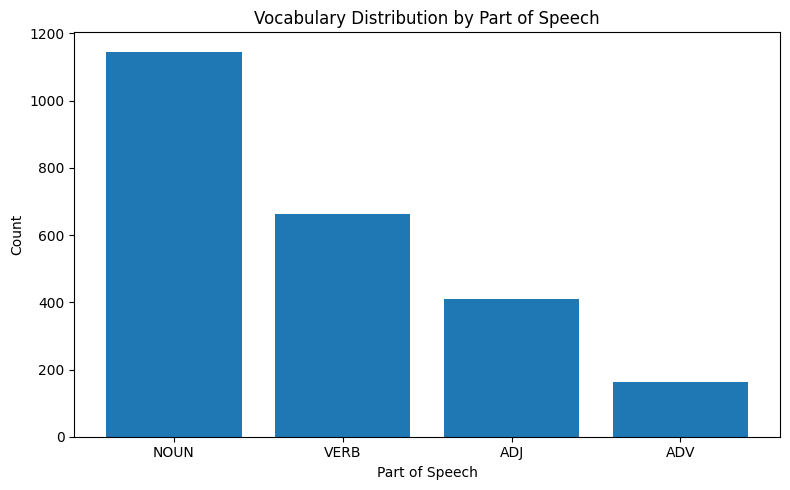

In [13]:
pos_counts = vocab_df["pos"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(pos_counts.index, pos_counts.values)
plt.xlabel("Part of Speech")
plt.ylabel("Count")
plt.title("Vocabulary Distribution by Part of Speech")
plt.tight_layout()
plt.show()

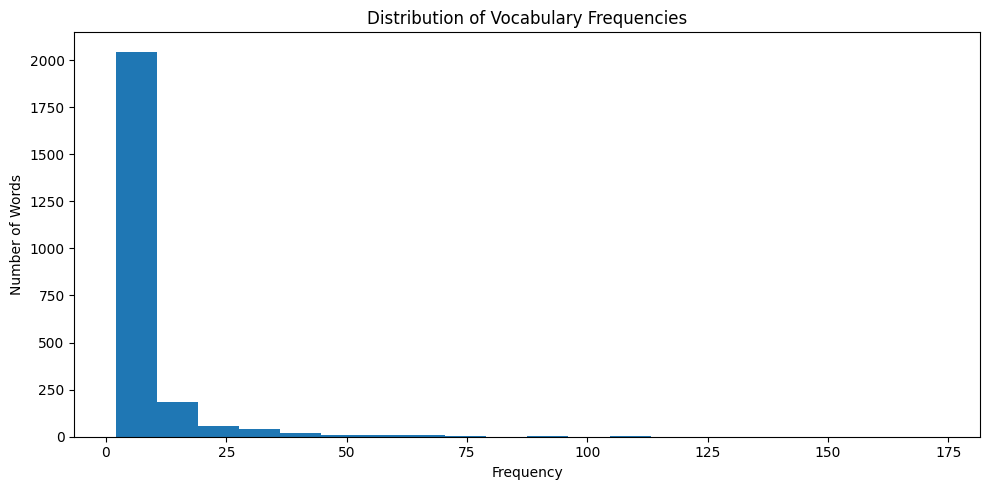

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(vocab_df["frequency"], bins=20)
plt.xlabel("Frequency")
plt.ylabel("Number of Words")
plt.title("Distribution of Vocabulary Frequencies")
plt.tight_layout()
plt.show()

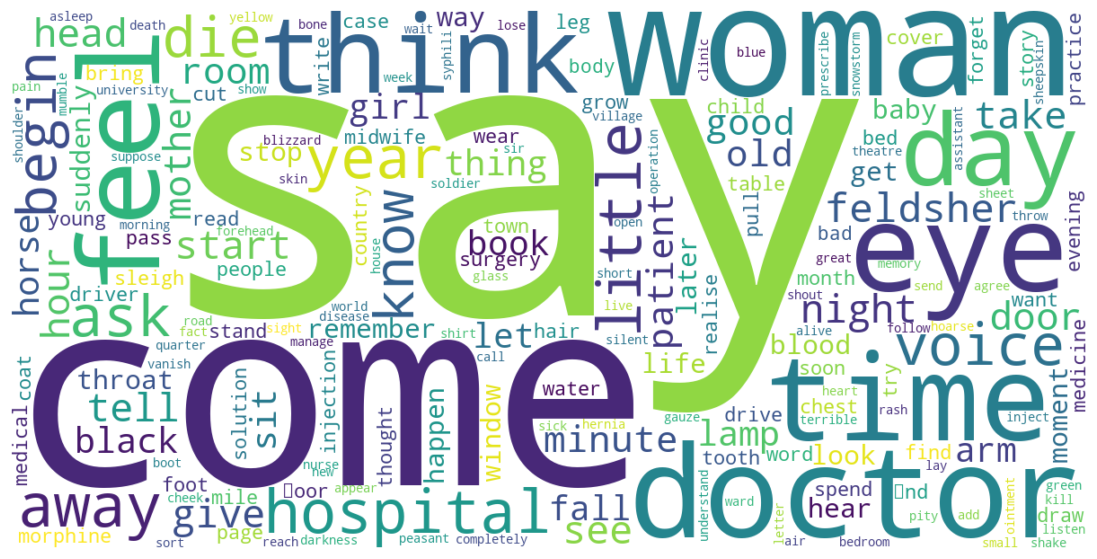

In [119]:
from wordcloud import WordCloud

freq_dict = dict(zip(vocab_df["lemma"], vocab_df["frequency"]))

wordcloud = WordCloud(width=1200, height=600, background_color="white").generate_from_frequencies(freq_dict)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## attach example sentences

This tries to find a decent sentence for each lemma.
If it can't find a strong one, it falls back to the best available match.


In [16]:
vocab_with_examples = add_example_sentences(vocab_df, text)

vocab_with_examples[["lemma", "frequency", "example_sentence"]].head(20)

,lemma,frequency,example_sentence
0,say,173,Do you know what they’re saying in the villages?
1,come,145,I turned round and saw that a round-faced old ...
2,woman,126,I turned round and saw that a round-faced old ...
3,doctor,120,A few minutes later I was standing beside the ...
4,eye,112,I raised her cold eyelid and looked with super...
5,time,105,All the time a ɹne rain was drizzling down as ...
6,look,94,And as you die a slow death there’s nothing to...
7,feel,91,Thereupon I regained my wits and started feeli...
8,think,91,Just think … I actually had to put up for the ...
9,man,82,and I saw a man hobbling towards me in a ragge...


In [17]:
vocab_with_examples.columns.tolist()

['lemma', 'pos', 'frequency', 'example_sentence']

In [18]:
vocab_with_examples.sample(10)

,lemma,pos,frequency,example_sentence
928,explain,VERB,4,We have a ɹre brigade there …’ the Roman expla...
2322,unsteady,ADJ,2,An unsteady white light was ɻickering in Casua...
1293,hypodermic,ADJ,3,Lying on a piece of gauze on the table was a h...
763,hardly,ADV,5,There was hardly a single one among a thousand...
112,page,NOUN,25,The pages of Döderlein ɻickered before my eyes.
1696,crack,NOUN,2,I could see one star through a crack—I think i...
2202,snatch,NOUN,2,The ɹrst blast of the snowstorm snatched me up...
1879,hay,NOUN,2,"I could hear the wild, shrill snorting of the ..."
683,absolute,ADJ,5,The absolute silence was only disturbed by the...
270,immediately,ADV,12,Someone was drumming loudly and insistently on...


In [19]:
vocab_with_examples["example_sentence"].isna().sum()

np.int64(0)

## rank the vocab

Raw frequency alone isn't great, so this adds a score that also considers how common the word is in general English.


In [20]:
ranked_vocab_df = rank_vocabulary(vocab_with_examples)

ranked_vocab_df[["lemma", "pos", "frequency", "zipf_frequency", "vocab_score", "example_sentence"]].head(20)

,lemma,pos,frequency,zipf_frequency,vocab_score,example_sentence
0,sleigh,NOUN,29,2.99,17.039999,I could hear the creaking of sleigh-runners in...
1,hoarse,ADJ,13,2.66,16.206451,‘ “A deserter?” croaked the now familiar hoars...
2,morphine,NOUN,32,3.37,16.188830,The morphine worked sooner than I had expected.
3,midwife,NOUN,28,3.27,15.927309,A midwife took a firm hold of the old woman an...
4,gauze,NOUN,20,2.89,15.557510,Lying on a piece of gauze on the table was a h...
5,gramme,NOUN,10,1.64,15.250614,There were only two syringes—a small one- gram...
6,sheepskin,NOUN,15,2.50,15.249238,Where are you from?’ The sheepskin coat fell i...
7,doctor,NOUN,120,4.90,14.866951,A few minutes later I was standing beside the ...
8,lamp,NOUN,40,4.05,14.668610,The pressure-lamp with its lopsided tin shade ...
9,syrinx,NOUN,9,1.83,14.206950,There were only two syringes—a small one- gram...


In [21]:
ranked_vocab_df[["lemma", "frequency", "zipf_frequency", "vocab_score"]].sample(20)

,lemma,frequency,zipf_frequency,vocab_score
1096,materialise,2,2.49,6.053354
2238,slow,2,4.85,3.460629
671,bang,6,4.32,7.160949
882,hard,9,5.53,6.540493
1175,edge,5,4.74,5.841136
1375,wave,4,4.62,5.439900
979,basin,4,4.08,6.308997
1269,favourable,2,3.53,5.647416
613,backwood,2,1.32,7.338730
1958,close,3,5.36,4.208790


In [22]:
ranked_vocab_df["zipf_frequency"].describe()

count    2382.000000
mean        4.092053
std         1.198951
min         0.000000
25%         3.580000
50%         4.320000
75%         4.900000
max         6.710000
Name: zipf_frequency, dtype: float64

## visualization of the ranked output


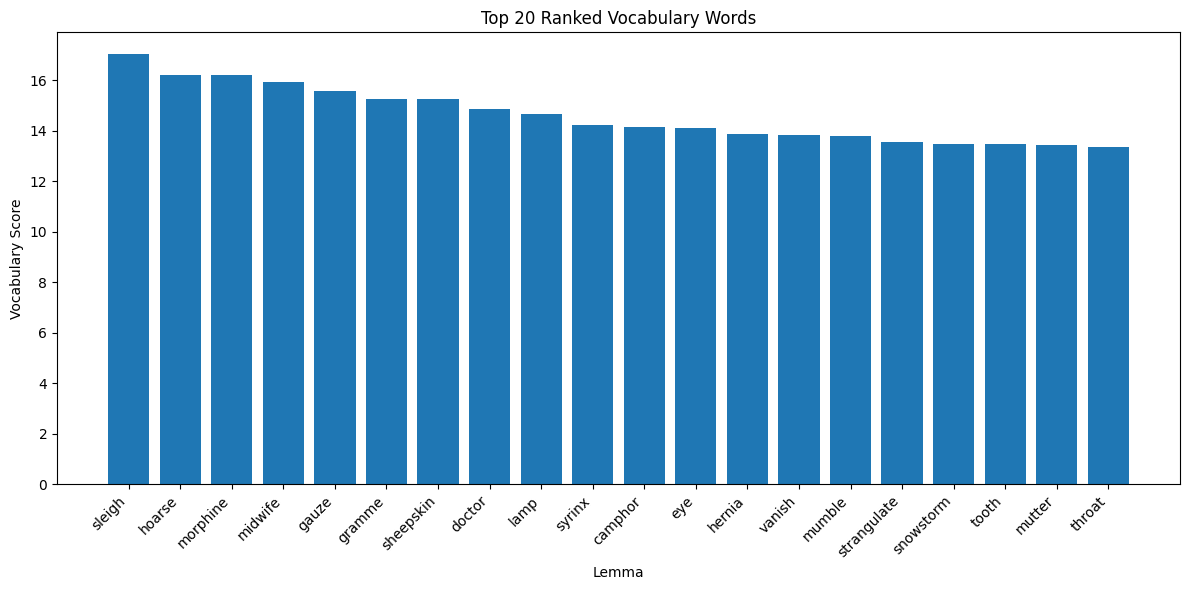

In [23]:
top_ranked = ranked_vocab_df.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_ranked["lemma"], top_ranked["vocab_score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lemma")
plt.ylabel("Vocabulary Score")
plt.title("Top 20 Ranked Vocabulary Words")
plt.tight_layout()
plt.show()

## save outputs


In [24]:
vocab_with_examples.to_csv("../outputs/vocabulary_with_examples.csv", index=False)
ranked_vocab_df.to_csv("../outputs/ranked_vocabulary.csv", index=False)